# Modeling: Predicting Hotel Booking Cancellations

In this notebook, I build predictive models to dermine whether a hotel booking will be cancelled.

I started by preparing the data for modeling, followed bu training nultiple classification models and evaluating their performance using metrics like accuracy, recall, precision, F1-score, and ROC-AUC

The goal is to identify key factors influencing cancellations and develop a reliable model that help hotels proactively manage bookings.

In [31]:
# Basic Imports
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    # precision_score,
    # recall_score,
    # f1_score,
    # roc_auc_score,
    # roc_curve
    )


# Settings
sns.set_theme(style='whitegrid')


In [3]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/hotel_bookings_cleaned.csv")

# Quick check
df.shape


(87396, 33)

---

## Feature Selection and Engineering

Next, I select relevant features for the modeling phase. I remove columns that are identifiers, have high missing values, or would not be available at the time of booking (such as reservation status)

In [4]:
# Drop columns that are not useful for prediction
drop_cols = [
    'reservation_status', 'reservation_status_date',  # Outcome-related
    'company', 'agent',                               # High missingness / IDs
    'country',                                        # Geographical analysis deferred
    'assigned_room_type', 'reserved_room_type',       # Room assignment happens after booking
    'meal',                                           # Not significant for cancellation prediction
    'distribution_channel'                           # To simplify model (optional)
]

# Create a modeling dataset
model_df = df.drop(columns=drop_cols)


# Quick check
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  int64  
 11  babies                          87396 non-null  int64  
 12  market_segment                  

### Preparing the Dataset for Modeling

To prepare the data for machine learning models, I needed to convert all categorical (object type) variables into numeric format. Since models like logistic regression and tree-based classifiers require numeric input, this was a critical preprocessing step.

I applied **Label Encoding** to the following categorical columns.

* `hotel`
* `arrival_date_month`
* `market_segment`
* `deposit_type`
* `customer_type`

After encoding, I verified that all columns were either `int64` or `float64`, with no object types remaining. 
This ensures the dataset is **completely ready for feature scaling, model training and evaluation.**


In [5]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to preserve the original
encoded_df = model_df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode each object column
for col in encoded_df.select_dtypes(include='object').columns:
    encoded_df[col] = le.fit_transform(encoded_df[col])

# Check if all features are now numeric
encoded_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  int64  
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  int64  
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  int64  
 11  babies                          87396 non-null  int64  
 12  market_segment                  

---

## Step 1: Train-Test Split

First, we split the data into features and target:

In [6]:
# Feature and Target
X = encoded_df.drop(columns='is_canceled')

y = encoded_df['is_canceled']

Now, we create the **training and testing sets** using an 80-20 split:

In [7]:
# Train-Test Split
X_test, X_train, y_test, y_train = train_test_split(X, y, 
                                                    stratify = y, 
                                                    test_size = 0.2, 
                                                    random_state = 42)

`stratify=y` ensures the class distribution (cancelled vs not cancelled) stays balanced between train and test sets.

### Train-Test Split Summary

Before building models, I seperated the dataset into **feature**(`X`) and **target**(`y`).
* Features include all variables except `is_canceled`
* Target is the binary outcome variable `is_canceled` (1 = cancelled, 0 = not cancelled)

I then split the dataset into training and testing sets, using an 80-20 ratio, while stratifying based on the target variable to preserve the class distribution across both sets.

This allows me to train models on one portion of the data and evaluate them fairly on unseen data. 

---

## Step 2: Baseline Model - Predict Majority Class

Before building complex models, I created **a simple baseline model** that always predicts the majaority class(most frequent outcome).

This gives a **benchmark** - any machine learning model we build must **perform better that this baseline**.

In [8]:
# Baseline Model:  Always predict the majority class
baseline_pred = [y_train.mode()[0]] * len(y_test)

# Baseline accuracy
baseline_accuracy =  accuracy_score(y_test, baseline_pred)
print(f'Baseline Accuracy: {baseline_accuracy:.4f}')

Baseline Accuracy: 0.7251


### Baseline Model Summary
To establish a performance baseline, I created a very simple model **that always predicts the most frequent class** observed in the training data (majority class prediction).

By evaluating the accuracy of this naive model, I could set a **minimum performance bar** that any real machine learning should beat.

This simple approach is crucial for contextualizing the effectiveness of more sophisticated models.

In this case, we have **Baseline Accuracy = 72.51%**. 

It means **if you always guessed "not canceled"**, you would be correct about **72.5%** of the time.
(**Remember**: Around 27–28% of bookings were canceled, based on earlier EDA — so this fits well.)

---



## Step 3: Training Models and Evaluation

### Model 1: Logistic Regression Model
I first trained a Logistic Regression model as an initial supervised learning approach to predict booking cancellations.
Logistic Regression is a strong baseline algorithm for binary classification problems like ours.

After training the model, I evaluated its performance using precision, recall, F1-score, and accuracy.

c:\Users\Vishnu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression Classifier Report ---
              precision    recall  f1-score   support

           0       0.78      0.95      0.86     50696
           1       0.71      0.29      0.41     19220

    accuracy                           0.77     69916
   macro avg       0.74      0.62      0.64     69916
weighted avg       0.76      0.77      0.74     69916


Confusion Matrix:


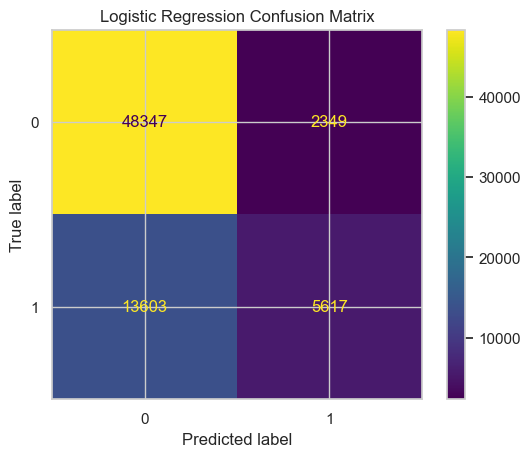

In [9]:
# Initialize the model
logreg = LogisticRegression(max_iter= 3000, random_state=42)

# Train the model
logreg.fit(X_train, y_train)

# Predict
y_pred = logreg.predict(X_test)

# Evaluation
print("\n--- Logistic Regression Classifier Report ---")
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


#### Logistic Regression Baseline Model - Evaluation

To establish a baseline, I trained a logistic regression model on the processed dataset.

- **Accuracy:** 77%
- **Precision:** 78% (non-canceled), 71% (canceled)
- **Recall:** 95% (non-canceled), 29% (canceled)

The model achieved better accuracy than the baseline (72.5%). However, the recall for canceled bookings was relatively low, indicating that the model struggles to correctly identify cancellations.

**Next Steps:** To address this, I plan to explore strategies such as data balancing, feature engineering, and testing alternative models like Random Forests and XGBoost to improve the cancellation prediction performance.


---

### Model 2: Random Forest Classifier

After establishing the logistic regression baseline, I moved on to training a Random Forest Classifier.  
Random Forests are powerful ensemble models that often perform better on complex, non-linear datasets compared to simple linear models.

My goal here is to:
* Improve recall for cancellation predictions.
* Improve the overall model robustness.

I used a simple Random Forest with basic hyperparameters for the initial test.



--- Random Forest Classifier Report ---
              precision    recall  f1-score   support

           0       0.83      0.92      0.87     50696
           1       0.70      0.49      0.58     19220

    accuracy                           0.80     69916
   macro avg       0.76      0.71      0.72     69916
weighted avg       0.79      0.80      0.79     69916


Confusion Matrix:


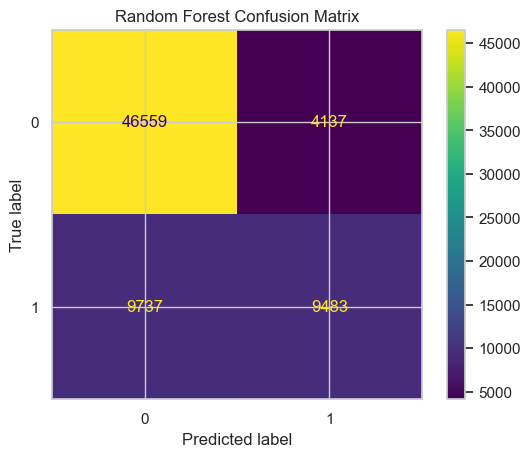

In [10]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators = 100,   # 100 trees
    random_state = 42,
    n_jobs = -1           # use all CPU cores
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest
print("\n--- Random Forest Classifier Report ---")
print(classification_report(y_test, y_pred_rf))

print('\nConfusion Matrix:')
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(values_format='')
plt.title('Random Forest Confusion Matrix')
plt.show()


### Random Forest Model - Evaluation

After training a Random Forest Classifier, I observed noticeable performance improvements compared to the baseline logistic regression:

- **Overall Accuracy:** Increased to 80%.
- **Precision:** 83% for non-cancellations (class 0), and 70% for cancellations (class 1).
- **Recall:** Improved to 49% for cancellation cases, compared to only 29% in the logistic regression baseline.
- **F1-Score:** Improved for both classes.

The Random Forest was more effective at detecting cancellations (positive class) while maintaining high precision.  
However, recall for cancellations still remained moderate, indicating room for further optimization.

**Next Step:** I planned to explore feature importance to better understand which factors were most influential in cancellation predictions.

---

## Feature Importance Analysis

To gain deeper insight into the Random Forest model, I analyzed feature importances. This helped identify which variables contributed most to the prediction of booking cancellations.
Understanding these drivers could also inform business strategies beyond model performance.


In [17]:
# Extracting feature importances from Random Forest model

importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a Dataframe and sort by importance
feat_imp_df = pd.DataFrame({'feature' : feature_names,
                            'importance' : importances}).sort_values(by = 'importance', ascending = False)

# Show the top 15 features
feat_imp_df.head(15)



,feature,importance
1,lead_time,0.179746
19,adr,0.138096
5,arrival_date_day_of_month,0.099284
4,arrival_date_week_number,0.077116
11,market_segment,0.065627
7,stays_in_week_nights,0.062121
21,total_of_special_requests,0.061281
6,stays_in_weekend_nights,0.038774
22,arrival_month_num,0.035756
3,arrival_date_month,0.035416


### Feature Importance (Random Forest)

To understand which features contributed the most to the model's decision-making, I extracted feature importances from the trained Random Forest classifier. This helps identify the most predictive variables influencing booking cancellations.

The bar chart below highlights the top 15 features based on their relative importance.


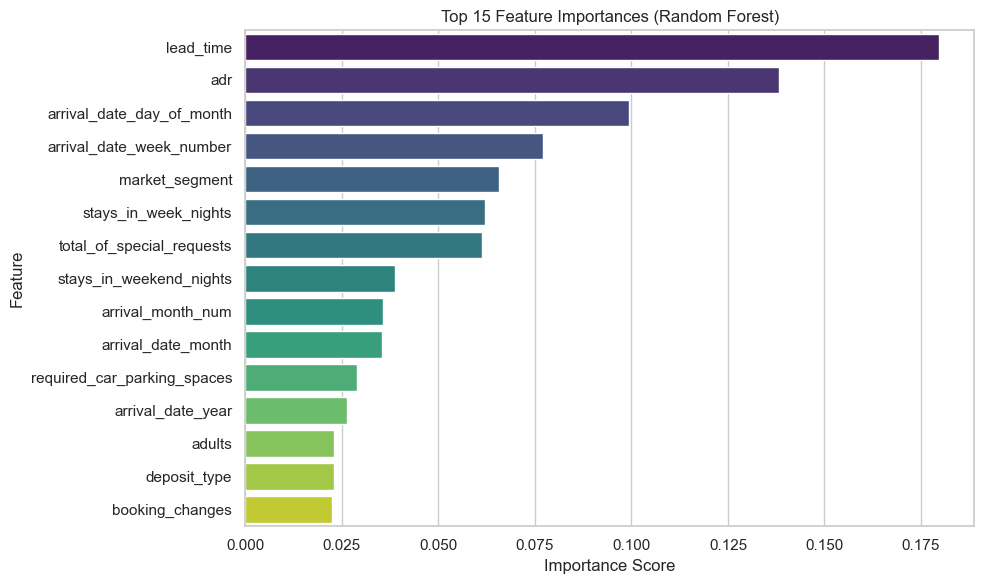

In [30]:
# Horizontal barplot of top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='importance', y = 'feature',hue = 'feature', palette='viridis')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Insights from Feature Importances

The Random Forest model identified **lead time**, **average daily rate (adr)**, and **arrival-related attributes** (e.g., day of month, week number) as the most important predictors for booking cancellations.

- **Lead Time** was the strongest predictor, reinforcing our earlier EDA that showed higher cancellation likelihood when bookings were made far in advance.
- **ADR (Average Daily Rate)** also ranked high, suggesting pricing dynamics play a significant role.
- Temporal features like **arrival_date_day_of_month** and **arrival_date_week_number** likely reflect seasonal and promotional trends.

This feature ranking helps prioritize variables for both predictive modeling and future business decision-making (e.g., marketing and pricing strategies).

---

## Gradient Boosting Classifier

To further explore ensemble learning, I trained a Gradient Boosting Classifier. Gradient Boosting builds models sequentially, each trying to correct the errors made by the previous ones. It's known for high predictive performance, especially on structured/tabular data.

This model helps test whether boosting can offer better predictive power or recall compared to the Random Forest model used earlier.


In [34]:
# Initialize and fit the model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

--- Gradient Boosting Classifier Report ---
              precision    recall  f1-score   support

           0       0.82      0.93      0.87     50696
           1       0.71      0.47      0.56     19220

    accuracy                           0.80     69916
   macro avg       0.77      0.70      0.72     69916
weighted avg       0.79      0.80      0.79     69916



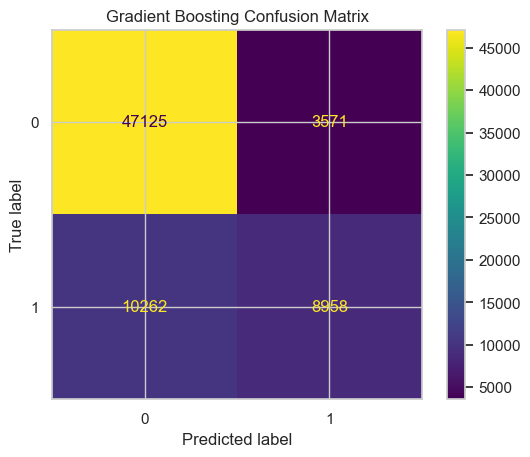

In [35]:
# Classification Report
print('--- Gradient Boosting Classifier Report ---')
print(classification_report(y_test, y_pred_gb))

# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp_gb.plot(values_format='')
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

### Model Evaluation Summary – Gradient Boosting Classifier

The Gradient Boosting Classifier achieved an overall accuracy of **80%**, matching the performance of the Random Forest model. Precision and F1-score remained strong for the majority class (non-cancelled bookings), while the minority class (cancelled bookings) had a **recall of 47%** and an **F1-score of 56%**.

Compared to Random Forest:
- Both models reached similar overall accuracy (80%)
- Gradient Boosting slightly improved the precision for cancellations
- However, it captured **fewer true positives** (cancelled bookings), as seen in the lower recall

While Gradient Boosting did not outperform Random Forest in this case, it still served as a valuable benchmark and confirmed the predictive potential of ensemble models.

---

## Final Model Comparison & Conclusion

After training and evaluating three supervised learning models on the hotel booking dataset, here is a comparative summary of their performance:

| Model                | Accuracy | Precision (Canceled) | Recall (Canceled) | F1-Score (Canceled) |
|---------------------|----------|-----------------------|--------------------|----------------------|
| **Logistic Regression** | 77%      | 0.71                  | 0.29               | 0.41                 |
| **Random Forest**        | 80%      | 0.70                  | 0.49               | 0.58                 |
| **Gradient Boosting**    | 80%      | 0.71                  | 0.47               | 0.56                 |

- **Random Forest** delivered the best balance between accuracy and F1-score for detecting cancellations.
- **Gradient Boosting** was close behind, performing slightly better in precision but slightly worse in recall.
- **Logistic Regression**, despite being interpretable, struggled to capture the minority class due to class imbalance.

### Next Steps:
- I plan to **use Random Forest predictions** in the Tableau dashboard for visual storytelling.
- I may revisit model tuning (e.g., `GridSearchCV`, SMOTE balancing) as a future enhancement.

With the modeling phase complete, I'm now ready to move to **dashboarding and storytelling using Tableau**.


---